In [33]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries loaded successfully ✅")


# ==============================
# STEP 2: LOAD DATASET
# ==============================

# Change path if needed
df = pd.read_csv("public_transport_delays.csv")

print("\nDataset loaded successfully ✅")


# ==============================
# STEP 3: BASIC DATA OVERVIEW
# ==============================

print("\n📌 First 5 rows:")
print(df.head())

print("\n📌 Dataset Shape:")
print(df.shape)

print("\n📌 Column Names:")
print(df.columns.tolist())


# ==============================
# STEP 4: DATASET INFO
# ==============================

print("\n📌 Dataset Info:")
df.info()


# ==============================
# STEP 5: STATISTICAL SUMMARY
# ==============================

print("\n📌 Statistical Summary:")
print(df.describe())


# ==============================
# STEP 6: MISSING VALUES CHECK
# ==============================

print("\n📌 Missing Values:")
print(df.isnull().sum())


# ==============================
# STEP 7: DUPLICATE CHECK
# ==============================

print("\n📌 Duplicate Rows:", df.duplicated().sum())

Libraries loaded successfully ✅

Dataset loaded successfully ✅

📌 First 5 rows:
  trip_id        date      time transport_type  route_id origin_station  \
0  T00000  2023-01-01  05:00:00           Tram  Route_15     Station_31   
1  T00001  2023-01-01  05:15:00          Metro  Route_12     Station_49   
2  T00002  2023-01-01  05:30:00            Bus  Route_16     Station_29   
3  T00003  2023-01-01  05:45:00           Tram  Route_19     Station_26   
4  T00004  2023-01-01  06:00:00           Tram   Route_8     Station_18   

  destination_station scheduled_departure scheduled_arrival  \
0           Station_6            05:02:00          05:55:00   
1          Station_32            05:16:00          05:55:00   
2          Station_42            05:33:00          06:17:00   
3          Station_18            05:49:00          06:08:00   
4          Station_15            06:00:00          06:35:00   

   actual_departure_delay_min  actual_arrival_delay_min weather_condition  \
0            

In [34]:
# ==============================
# DATA CLEANING
# ==============================

df_clean = df.copy()

# 1. Drop unnecessary columns
df_clean.drop(columns=[
    "trip_id",
    "actual_departure_delay_min"
], inplace=True)

# 2. Handle missing values
df_clean["event_type"].fillna("None", inplace=True)

# 3. Convert date & time (optional feature extraction)
df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean["time"] = pd.to_datetime(df_clean["time"])

# Extract useful features
df_clean["hour"] = df_clean["time"].dt.hour
df_clean["month"] = df_clean["date"].dt.month

# Drop original columns
df_clean.drop(columns=["date", "time"], inplace=True)

print("✅ Data Cleaning Done")
print(df_clean.head())

✅ Data Cleaning Done
  transport_type  route_id origin_station destination_station  \
0           Tram  Route_15     Station_31           Station_6   
1          Metro  Route_12     Station_49          Station_32   
2            Bus  Route_16     Station_29          Station_42   
3           Tram  Route_19     Station_26          Station_18   
4           Tram   Route_8     Station_18          Station_15   

  scheduled_departure scheduled_arrival  actual_arrival_delay_min  \
0            05:02:00          05:55:00                         3   
1            05:16:00          05:55:00                         9   
2            05:33:00          06:17:00                         0   
3            05:49:00          06:08:00                        10   
4            06:00:00          06:35:00                        14   

  weather_condition  temperature_C  humidity_percent  wind_speed_kmh  \
0             Storm            5.1                52              46   
1              Rain          

/tmp/ipykernel_795/791024594.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["event_type"].fillna("None", inplace=True)
/tmp/ipykernel_795/791024594.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["time"] = pd.to_datetime(df_clean["time"])


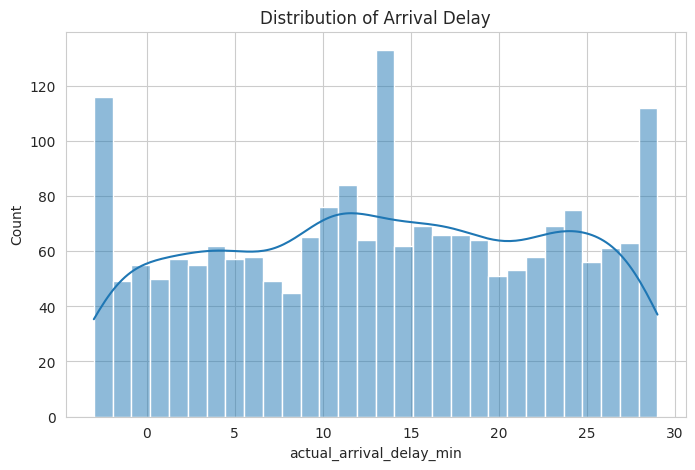

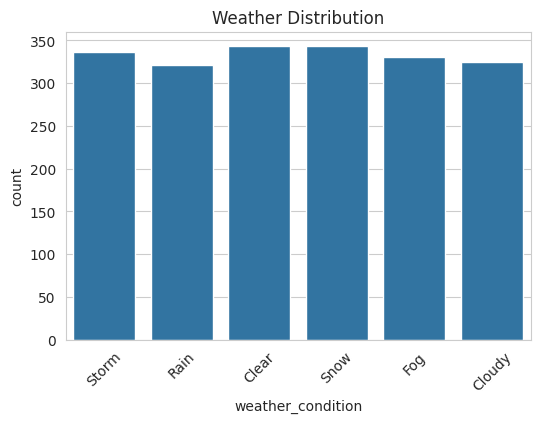

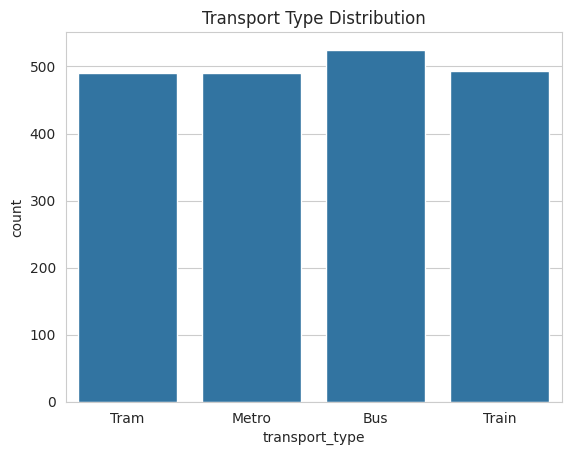

In [35]:
# ==============================
# UNIVARIATE ANALYSIS
# ==============================

# Target variable distribution
plt.figure(figsize=(8,5))
sns.histplot(df_clean["actual_arrival_delay_min"], bins=30, kde=True)
plt.title("Distribution of Arrival Delay")
plt.show()

# Weather distribution
plt.figure(figsize=(6,4))
sns.countplot(x="weather_condition", data=df_clean)
plt.xticks(rotation=45)
plt.title("Weather Distribution")
plt.show()

# Transport type
sns.countplot(x="transport_type", data=df_clean)
plt.title("Transport Type Distribution")
plt.show()

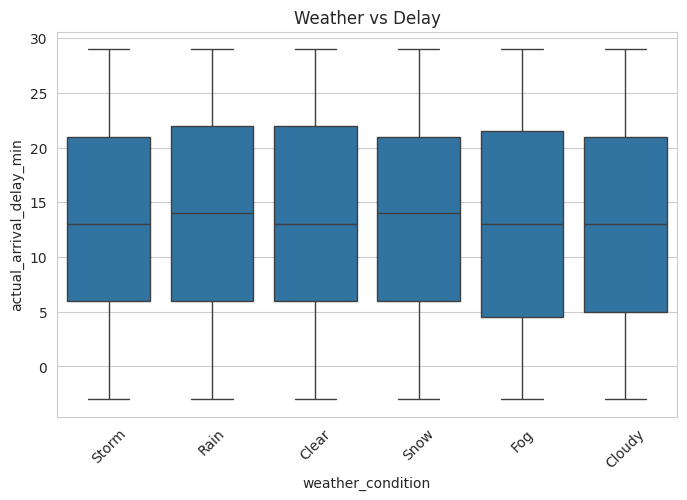

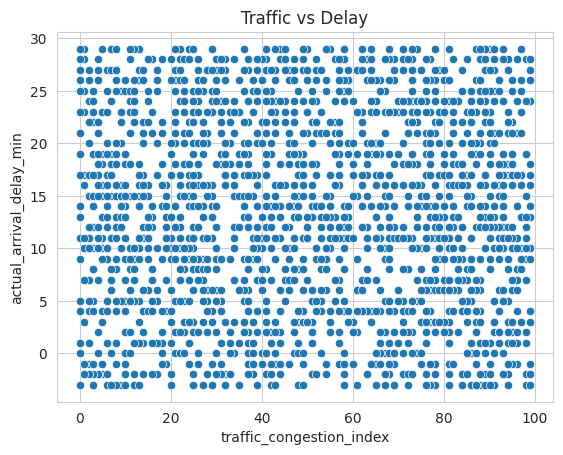

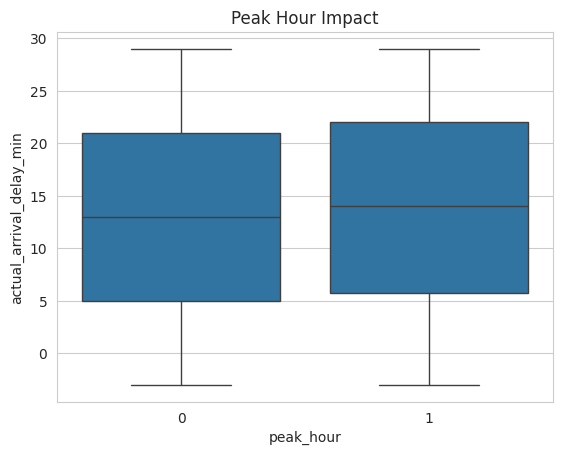

In [36]:
# ==============================
# BIVARIATE ANALYSIS
# ==============================

# Weather vs Delay
plt.figure(figsize=(8,5))
sns.boxplot(x="weather_condition", y="actual_arrival_delay_min", data=df_clean)
plt.xticks(rotation=45)
plt.title("Weather vs Delay")
plt.show()

# Traffic vs Delay
sns.scatterplot(x="traffic_congestion_index", y="actual_arrival_delay_min", data=df_clean)
plt.title("Traffic vs Delay")
plt.show()

# Peak hour vs delay
sns.boxplot(x="peak_hour", y="actual_arrival_delay_min", data=df_clean)
plt.title("Peak Hour Impact")
plt.show()

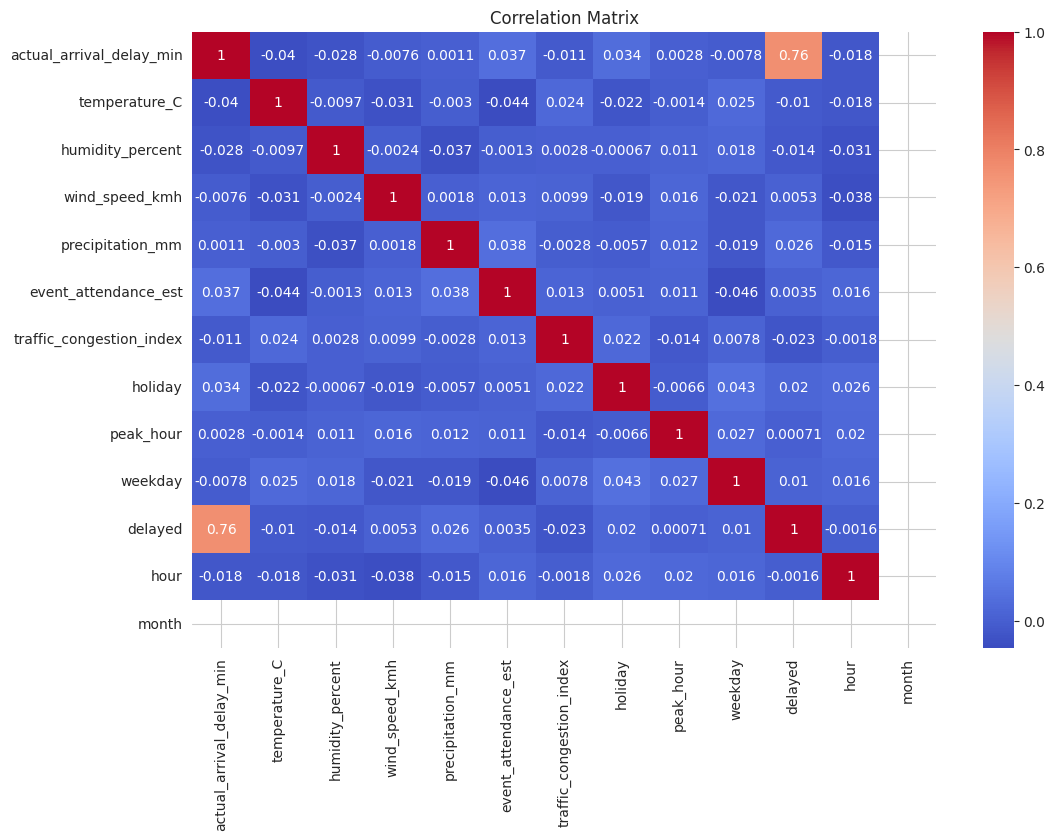

In [37]:
# ==============================
# MULTIVARIATE ANALYSIS
# ==============================

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [38]:
# Check what variables exist
print("df_clean exists:", 'df_clean' in globals())
print("df_better exists:", 'df_better' in globals())
print("X exists:", 'X' in globals())
print("model exists:", 'model' in globals())

df_clean exists: True
df_better exists: True
X exists: False
model exists: True


In [39]:
# ==============================
# STEP 1: PREPARE DATA AGAIN
# ==============================

df_better = df_clean.copy()

# Drop high-cardinality columns (important)
df_better.drop(columns=[
    "route_id",
    "origin_station",
    "destination_station"
], inplace=True)

# Define target
y = df_better["actual_arrival_delay_min"]

# Features
X = df_better.drop(columns=["actual_arrival_delay_min", "delayed"], errors='ignore')

print("✅ Data prepared")
print("Shape:", X.shape)

✅ Data prepared
Shape: (2000, 17)


In [40]:
# ==============================
# STEP 2: ENCODING
# ==============================

X_encoded = pd.get_dummies(X, drop_first=True)

print("✅ Encoding done")
print("Shape after encoding:", X_encoded.shape)

✅ Encoding done
Shape after encoding: (2000, 1567)


In [41]:
# ==============================
# STEP 3: DROP HIGH CARDINALITY COLUMNS
# ==============================

X_reduced = X.copy()

# Drop problematic columns
X_reduced.drop(columns=[
    "transport_type",   # optional (can keep later)
    "scheduled_departure",
    "scheduled_arrival"
], inplace=True, errors='ignore')

# Encode again
X_reduced_encoded = pd.get_dummies(X_reduced, drop_first=True)

print("✅ Features reduced")
print("New shape:", X_reduced_encoded.shape)
print("Columns:", X_reduced_encoded.columns[:10])

✅ Features reduced
New shape: (2000, 24)
Columns: Index(['temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'hour'],
      dtype='object')


In [42]:
# ==============================
# STEP 4: TRAIN-TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1600, 24)
Test shape: (400, 24)


In [43]:
# ==============================
# STEP 5: TRAIN MODEL
# ==============================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained successfully")

✅ Model trained successfully


In [44]:
# ==============================
# STEP 6: EVALUATION
# ==============================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 7.856325872770099
RMSE: 9.396584994583291
R2 Score: -0.0472163337971061


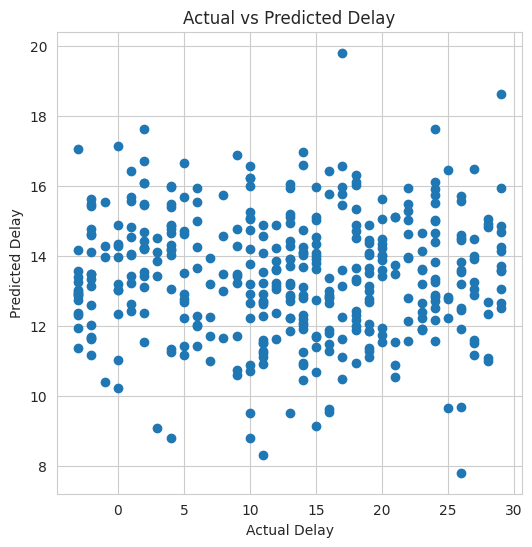

In [45]:
# ==============================
# ACTUAL vs PREDICTED
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted Delay")
plt.show()

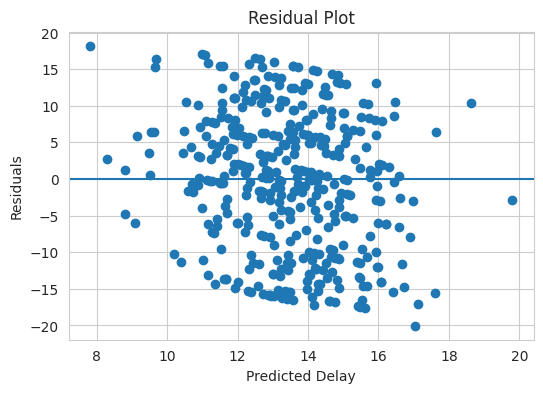

In [46]:
# ==============================
# RESIDUAL PLOT
# ==============================

residuals = y_test - pred

plt.figure(figsize=(6,4))
plt.scatter(pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Delay")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [47]:
# ==============================
# FEATURE IMPORTANCE
# ==============================

import pandas as pd

importances = model.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_df.head(10))

                     feature  importance
0              temperature_C    0.153597
3           precipitation_mm    0.139260
5   traffic_congestion_index    0.129319
1           humidity_percent    0.117662
2             wind_speed_kmh    0.108981
9                       hour    0.095283
8                    weekday    0.055741
4       event_attendance_est    0.034711
17           event_type_None    0.013695
7                  peak_hour    0.013479


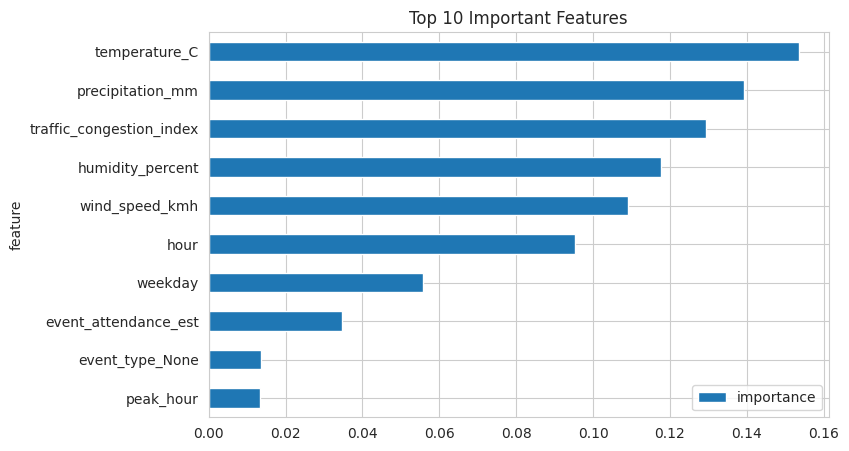

In [48]:
feat_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [49]:
# ==============================
# CROSS VALIDATION
# ==============================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_reduced_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_scores = -cv_scores  # convert to positive

print("Cross-validation MAE scores:", cv_scores)
print("Average MAE:", cv_scores.mean())

Cross-validation MAE scores: [7.59034633 8.22848866 7.9235995  8.14598825 8.16212943]
Average MAE: 8.010110435278147


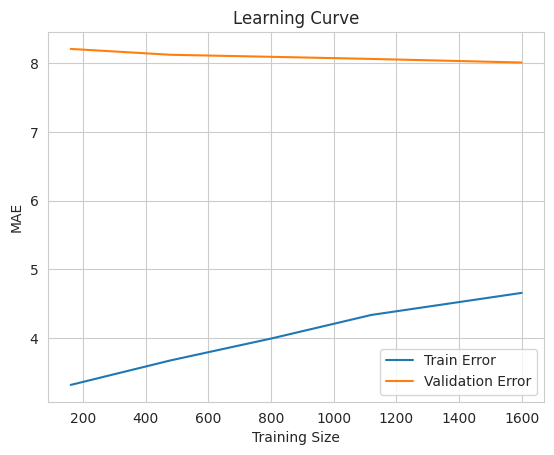

In [50]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_reduced_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error",
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0]
)

train_scores = -train_scores
val_scores = -val_scores

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Error")
plt.plot(train_sizes, val_mean, label="Validation Error")
plt.xlabel("Training Size")
plt.ylabel("MAE")
plt.title("Learning Curve")
plt.legend()
plt.show()

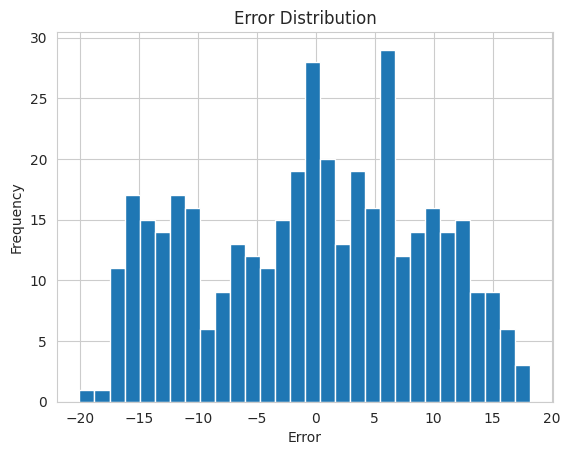

In [51]:
# ==============================
# ERROR DISTRIBUTION
# ==============================

errors = y_test - pred

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [52]:
# ==============================
# SAVE MODEL + FEATURES
# ==============================

import joblib

# Save model
joblib.dump(model, "delay_model.pkl")

# Save feature columns (IMPORTANT)
joblib.dump(X_reduced_encoded.columns, "features.pkl")

print("✅ Model and features saved successfully!")

✅ Model and features saved successfully!
